# 05 — Backtesting para la estrategia DOGE

Este notebook implementa un sistema de backtesting más realista para evaluar la estrategia de trading sobre DOGE/USDT. A diferencia del notebook de baseline, aquí no se evalúa el modelo únicamente como clasificador, sino como componente de decisión dentro de una estrategia de trading.

El backtest proporciona una evaluación más realista que las métricas de clasificación aisladas, ya que incorpora costes de transacción, reglas de gestión de posición e indicadores de riesgo.

La curva de equity muestra cómo evoluciona el valor de la cartera durante el periodo de test. El gráfico de drawdown permite observar la profundidad de las pérdidas respecto al máximo anterior de la cartera. Esta métrica es especialmente importante en trading, porque una estrategia puede tener rentabilidad positiva y aun así sufrir caídas intermedias difíciles de asumir.

La comparación contra Buy & Hold sirve como referencia mínima. Si el mercado sube mucho durante el periodo de test, una estrategia activa puede obtener beneficio simplemente por estar expuesta al activo. Por eso es necesario comprobar si realmente mejora frente a comprar y mantener.

El backtesting incluye:

- Curva de equity
- Drawdown
- Comisiones por operación
- Cooldown entre operaciones
- Reglas de Take Profit y Stop Loss
- Comparación contra Buy & Hold
- Métricas resumen
- Visualización de compras y ventas sobre el precio

En el notebook anterior se entrenaron y guardaron tres modelos: Linear Regression, Random Forest y XGBoost. Para esta primera fase de backtesting se utilizará XGBoost, ya que fue el modelo que mostró mejores resultados iniciales como baseline predictivo.

# Objetivo

El objetivo de este notebook es comprobar si el modelo de machine learning puede generar señales de trading con sentido financiero bajo unas condiciones de simulación más realistas.

Hasta ahora se habían analizado métricas clásicas de clasificación, como accuracy, precision, recall y F1-score. Sin embargo, en un sistema de trading estas métricas no son suficientes. Un modelo puede acertar razonablemente bien la dirección del precio y aun así perder dinero si opera demasiado, si entra tarde, si no controla las pérdidas o si las comisiones se comen el beneficio.

En este notebook se analiza:

- Cómo evoluciona el valor total de la cartera a lo largo del tiempo
- Qué pérdidas máximas se producen durante los periodos desfavorables
- Si la estrategia mejora o no a una estrategia pasiva de Buy & Hold
- Qué efecto tienen las comisiones, el cooldown y las reglas de salida

In [1]:
# ============================================================
# Imports and configuration
# En esta celda se importan las librerías necesarias para el backtesting y se definen los parámetros principales de la simulación.
# También se fijan las rutas del modelo XGBoost guardado en el notebook de baseline y del dataset procesado con features.
# Estos parámetros se dejan agrupados al inicio para poder ajustar fácilmente el comportamiento de la estrategia.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib

# Configuración general del backtest
INITIAL_BALANCE = 1000
FEE_RATE = 0.001          # Comisión por operación: 0.1%
COOLDOWN_BARS = 12        # Número de velas de espera tras cerrar una posición
TP_PCT = 0.03             # Take Profit: +3%
SL_PCT = 0.02             # Stop Loss: -2%
BUY_THRESHOLD = 0.55      # Probabilidad mínima para abrir posición
SELL_THRESHOLD = 0.45     # Umbral de probabilidad para forzar salida

# Modelo principal seleccionado para el primer backtest serio
MODEL_PATH = Path("../models/xgboost.joblib")
DATA_PATH = Path("../data/processed/DOGEUSDT_5m_binance_2017_2026_features.csv")

In [2]:
# ============================================================
# Load model and dataset
# En esta sección se carga el modelo XGBoost guardado en el notebook anterior junto con la lista de variables utilizadas durante el entrenamiento.
# El fichero del modelo contiene la estructura guardada en el notebook de baseline: modelo, columnas feature y target.
# Esta estructura permite reutilizar exactamente las mismas variables durante el backtesting, evitando inconsistencias entre entrenamiento y evaluación.
# ============================================================

bundle = joblib.load(MODEL_PATH)

model = bundle["model"]
feature_cols = bundle["feature_cols"]
target = bundle["target"]

print("Modelo cargado correctamente")
print("Target del modelo:", target)
print("Número de features:", len(feature_cols))
print("Tipo de modelo:", type(model))

# Load processed dataset
df = pd.read_csv(DATA_PATH)

# Conversión de fecha si existe la columna temporal
if "open_time" in df.columns:
    df["open_time"] = pd.to_datetime(df["open_time"])

print("Shape del dataset:", df.shape)
df.head()

Modelo cargado correctamente
Target del modelo: up_1
Número de features: 30
Tipo de modelo: <class 'xgboost.sklearn.XGBClassifier'>
Shape del dataset: (723348, 44)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,...,up_1,future_close_3,future_return_3,up_3,future_close_6,future_return_6,up_6,future_close_12,future_return_12,up_12
0,2019-07-05 13:35:00,0.003815,0.003817,0.003785,0.003809,5726661.0,2019-07-05 13:39:59.999,21762.784020,91,2358281.0,...,1,0.003800,-0.002389,0,0.003822,0.003413,1,0.003863,0.014072,1
1,2019-07-05 13:40:00,0.003812,0.003885,0.003812,0.003840,16701268.0,2019-07-05 13:44:59.999,64066.264668,158,10516524.0,...,0,0.003835,-0.001328,0,0.003836,-0.001198,0,0.003855,0.003776,1
2,2019-07-05 13:45:00,0.003842,0.003880,0.003831,0.003840,21970773.0,2019-07-05 13:49:59.999,84686.627401,137,4464170.0,...,0,0.003831,-0.002344,0,0.003860,0.005287,1,0.003850,0.002787,1
3,2019-07-05 13:50:00,0.003835,0.003860,0.003800,0.003800,6436340.0,2019-07-05 13:54:59.999,24591.400060,90,1357970.0,...,1,0.003822,0.005816,1,0.003919,0.031316,1,0.003867,0.017632,1
4,2019-07-05 13:55:00,0.003820,0.003840,0.003806,0.003835,7182776.0,2019-07-05 13:59:59.999,27471.432703,75,4783851.0,...,0,0.003836,0.000130,1,0.003864,0.007405,1,0.003841,0.001564,1


In [3]:
# ============================================================
# Prepare temporal test set
# Se mantiene una partición cronológica, igual que en los notebooks anteriores.
# En series temporales no debemos mezclar aleatoriamente pasado y futuro, porque eso introduciría leakage temporal.
# La idea es simular una situación realista: el modelo aprende del pasado y se evalúa sobre un periodo posterior no visto durante el entrenamiento.
# ============================================================

# Columnas mínimas necesarias para el backtest
required_cols = feature_cols + ["close"]

# Si existe la variable objetivo usada por el modelo, también la conservamos para posibles análisis posteriores
if target in df.columns:
    required_cols.append(target)

df_model = df.dropna(subset=required_cols).copy()

split_idx = int(len(df_model) * 0.8)
df_train = df_model.iloc[:split_idx].copy()
df_test = df_model.iloc[split_idx:].copy()

print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

if "open_time" in df_test.columns:
    print("Periodo de test:")
    print(df_test["open_time"].min(), "->", df_test["open_time"].max())

Train shape: (578678, 44)
Test shape: (144670, 44)
Periodo de test:
2025-01-06 02:25:00 -> 2026-05-23 10:10:00


In [4]:
# ============================================================
# Generate model probabilities
# Para trading resulta más útil trabajar con probabilidades que con una predicción binaria directa.
# Una predicción 0/1 solo indica la clase estimada, mientras que la probabilidad permite aplicar filtros de confianza.
# Por ejemplo, se puede exigir una probabilidad mínima de subida del 55% para comprar y evitar operar cuando el modelo apenas muestra convicción (variables definidas en la configuración inicial)
# ============================================================

X_test = df_test[feature_cols]

# Probabilidad de clase 1: subida del precio en el horizonte objetivo
proba_up = model.predict_proba(X_test)[:, 1]

bt_input = df_test.copy().reset_index(drop=True)
bt_input["proba_up"] = proba_up
bt_input["prediction"] = (bt_input["proba_up"] >= 0.5).astype(int)

bt_input[["close", "proba_up", "prediction"]].head()

,close,proba_up,prediction
0,0.38713,0.459977,0
1,0.38857,0.447670,0
2,0.38806,0.451843,0
3,0.38802,0.503044,1
4,0.38777,0.470510,0


In [5]:
# ============================================================
# Backtesting engine
# Esta función simula una estrategia long-only en mercado spot.
# La estrategia empieza con un capital inicial en USDT, solo puede tener una posición abierta y utiliza el capital disponible al comprar.
# El motor incorpora comisiones, cooldown, Take Profit, Stop Loss y salida por señal del modelo.
# ============================================================

def run_backtest(
    df,
    prob_col="proba_up",
    price_col="close",
    initial_balance=INITIAL_BALANCE,
    fee_rate=FEE_RATE,
    cooldown_bars=COOLDOWN_BARS,
    tp_pct=TP_PCT,
    sl_pct=SL_PCT,
    buy_threshold=BUY_THRESHOLD,
    sell_threshold=SELL_THRESHOLD,
):
    df = df.copy().reset_index(drop=True)

    cash = initial_balance
    position = 0.0
    entry_price = None
    cooldown = 0

    equity_curve = []
    actions = []
    position_values = []
    cash_values = []
    entry_prices = []
    exit_reasons = []

    for _, row in df.iterrows():
        price = row[price_col]
        proba = row[prob_col]

        action = "HOLD"
        exit_reason = None

        if cooldown > 0:
            cooldown -= 1

        # Lógica de salida
        if position > 0:
            pnl_pct = (price - entry_price) / entry_price

            hit_tp = pnl_pct >= tp_pct
            hit_sl = pnl_pct <= -sl_pct
            model_exit = proba < sell_threshold

            if hit_tp or hit_sl or model_exit:
                cash = position * price * (1 - fee_rate)
                position = 0.0
                entry_price = None
                cooldown = cooldown_bars
                action = "SELL"

                if hit_tp:
                    exit_reason = "TP"
                elif hit_sl:
                    exit_reason = "SL"
                else:
                    exit_reason = "MODEL_EXIT"

        # Lógica de entrada
        elif cooldown == 0 and proba > buy_threshold:
            position = (cash * (1 - fee_rate)) / price
            cash = 0.0
            entry_price = price
            action = "BUY"

        equity = cash + position * price

        equity_curve.append(equity)
        actions.append(action)
        position_values.append(position * price)
        cash_values.append(cash)
        entry_prices.append(entry_price)
        exit_reasons.append(exit_reason)

    df["equity"] = equity_curve
    df["action"] = actions
    df["position_value"] = position_values
    df["cash"] = cash_values
    df["entry_price"] = entry_prices
    df["exit_reason"] = exit_reasons

    df["strategy_return"] = df["equity"].pct_change().fillna(0)
    df["equity_cummax"] = df["equity"].cummax()
    df["drawdown"] = (df["equity"] / df["equity_cummax"]) - 1

    return df

In [6]:
# ============================================================
# Buy and Hold benchmark
# Esta función calcula el rendimiento de una estrategia pasiva de Buy & Hold.
# El benchmark compra DOGE al inicio del periodo de test y mantiene la posición hasta el final.
# Esta comparación es imprescindible porque una estrategia activa no solo debe ganar dinero, también debería justificar que aporta valor frente a comprar y esperar.
# ============================================================

def add_buy_and_hold(df, price_col="close", initial_balance=INITIAL_BALANCE, fee_rate=FEE_RATE):
    df = df.copy().reset_index(drop=True)

    first_price = df.loc[0, price_col]
    units = (initial_balance * (1 - fee_rate)) / first_price

    df["buy_hold_equity"] = units * df[price_col]
    df["buy_hold_return"] = df["buy_hold_equity"].pct_change().fillna(0)
    df["buy_hold_cummax"] = df["buy_hold_equity"].cummax()
    df["buy_hold_drawdown"] = (df["buy_hold_equity"] / df["buy_hold_cummax"]) - 1

    return df

In [7]:
# ============================================================
# Run backtest
# En esta celda se ejecuta la estrategia sobre el conjunto de test y se añade la comparación con Buy & Hold.
# El resultado es un dataframe enriquecido con equity, drawdown, acciones realizadas y motivo de salida de cada operación.
# Estas columnas permiten analizar tanto el rendimiento financiero como el comportamiento operativo de la estrategia.
# ============================================================

bt = run_backtest(bt_input)
bt = add_buy_and_hold(bt)

bt[["close", "proba_up", "action", "exit_reason", "equity", "drawdown", "buy_hold_equity", "buy_hold_drawdown"]].head()

bt["action"].value_counts()

bt["exit_reason"].value_counts(dropna=False)

exit_reason
None          143563
MODEL_EXIT       789
SL               286
TP                32
Name: count, dtype: int64

### Interpretación de los motivos de salida

La mayoría de las operaciones cerradas se producen mediante señales de salida generadas por el propio modelo (`MODEL_EXIT`), mientras que los eventos de Take Profit son considerablemente menos frecuentes.

Por el contrario, el número de Stop Loss activados es relativamente elevado en comparación con los Take Profit alcanzados. Esto refuerza la idea de que el sistema opera en un entorno desfavorable para estrategias long-only, donde las subidas sostenidas son escasas y los movimientos bajistas dominan gran parte del periodo analizado.

El bajo número de operaciones cerradas mediante Take Profit sugiere además que el modelo tiene dificultades para capturar tendencias alcistas suficientemente amplias como para compensar pérdidas, comisiones y ruido de mercado.

In [8]:
# ============================================================
# Summary metrics
# Esta sección calcula métricas financieras para comparar la estrategia activa contra Buy & Hold de forma compacta.
# Se analizan balance final, rentabilidad total, drawdown máximo, número de operaciones y Sharpe aproximado.
# El Sharpe se calcula sobre retornos de velas de 5 minutos, anualizando con 365 * 24 * 12, ya que hay 12 velas de 5 minutos por hora.
# ============================================================

def summarize_strategy(bt, equity_col="equity", return_col="strategy_return", drawdown_col="drawdown"):
    final_balance = bt[equity_col].iloc[-1]
    total_return = final_balance / INITIAL_BALANCE - 1
    max_drawdown = bt[drawdown_col].min()

    trades = bt[bt["action"].isin(["BUY", "SELL"])]
    num_buys = (bt["action"] == "BUY").sum()
    num_sells = (bt["action"] == "SELL").sum()

    returns_std = bt[return_col].std()
    sharpe_approx = (
        bt[return_col].mean() / returns_std * np.sqrt(365 * 24 * 12)
        if returns_std != 0
        else np.nan
    )

    return pd.Series({
        "final_balance": final_balance,
        "total_return_%": total_return * 100,
        "max_drawdown_%": max_drawdown * 100,
        "num_trades": len(trades),
        "num_buys": num_buys,
        "num_sells": num_sells,
        "sharpe_approx": sharpe_approx,
    })


def summarize_buy_hold(bt):
    final_balance = bt["buy_hold_equity"].iloc[-1]
    total_return = final_balance / INITIAL_BALANCE - 1
    max_drawdown = bt["buy_hold_drawdown"].min()

    returns_std = bt["buy_hold_return"].std()
    sharpe_approx = (
        bt["buy_hold_return"].mean() / returns_std * np.sqrt(365 * 24 * 12)
        if returns_std != 0
        else np.nan
    )

    return pd.Series({
        "final_balance": final_balance,
        "total_return_%": total_return * 100,
        "max_drawdown_%": max_drawdown * 100,
        "num_trades": 1,
        "num_buys": 1,
        "num_sells": 0,
        "sharpe_approx": sharpe_approx,
    })

summary = pd.DataFrame({
    "Strategy": summarize_strategy(bt),
    "Buy & Hold": summarize_buy_hold(bt),
}).T

summary    

,final_balance,total_return_%,max_drawdown_%,num_trades,num_buys,num_sells,sharpe_approx
Strategy,83.959344,-91.604066,-91.804068,2214.0,1107.0,1107.0,-3.702106
Buy & Hold,256.891613,-74.310839,-81.410760,1.0,1.0,0.0,-0.469172


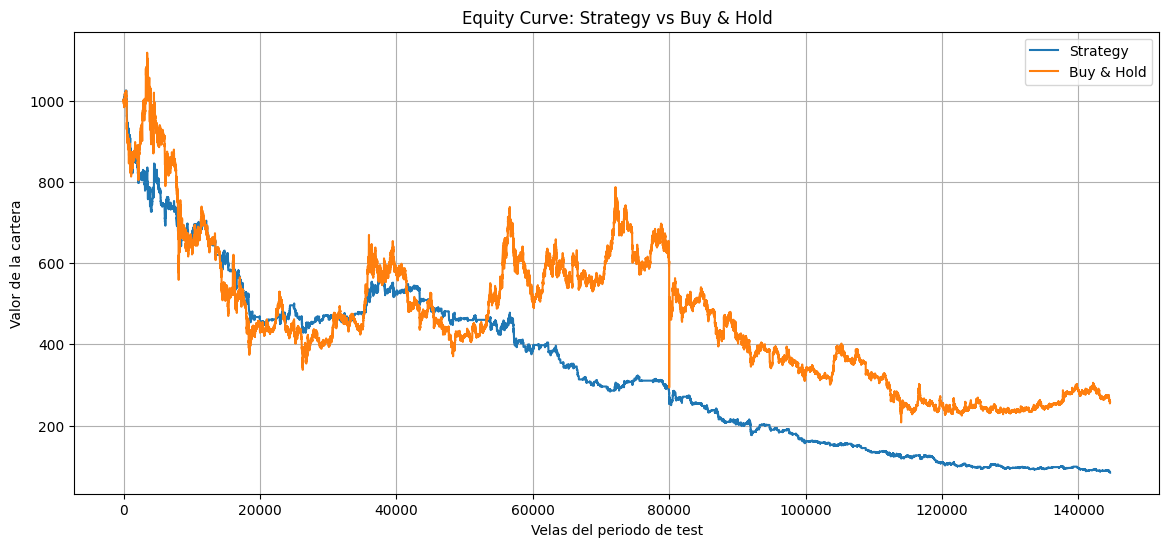

In [9]:
# ============================================================
# Equity curve comparison
# Esta visualización compara la evolución del valor de la cartera de la estrategia frente al benchmark Buy & Hold.
# La curva de equity permite observar si la estrategia crece de forma estable, si atraviesa periodos laterales o si sufre caídas relevantes.
# Esta gráfica es una de las más importantes para interpretar el comportamiento financiero del sistema.
# ============================================================

plt.figure(figsize=(14, 6))
plt.plot(bt["equity"], label="Strategy")
plt.plot(bt["buy_hold_equity"], label="Buy & Hold")
plt.title("Equity Curve: Strategy vs Buy & Hold")
plt.xlabel("Velas del periodo de test")
plt.ylabel("Valor de la cartera")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación de la curva de equity

La curva de equity muestra que tanto la estrategia activa como el benchmark Buy & Hold sufren una pérdida significativa de valor durante el periodo de test. Esto sugiere que el conjunto evaluado corresponde a un régimen de mercado predominantemente bajista, caracterizado por caídas prolongadas y elevada presión vendedora.

Aunque la estrategia basada en XGBoost consigue evitar parcialmente algunas caídas iniciales, su rendimiento termina siendo inferior al de Buy & Hold. La cartera pierde valor de forma relativamente constante hasta estabilizarse cerca de mínimos durante la parte final del periodo.

Este comportamiento pone de manifiesto una limitación importante del sistema actual: la estrategia únicamente opera posiciones long. En un entorno de mercado claramente bajista, una estrategia de este tipo parte con una desventaja estructural, ya que depende de movimientos alcistas para generar beneficio.

El resultado también evidencia que obtener métricas de clasificación razonables no implica necesariamente construir una estrategia rentable. La dirección general del mercado y el régimen temporal tienen un impacto dominante sobre el rendimiento financiero del sistema.

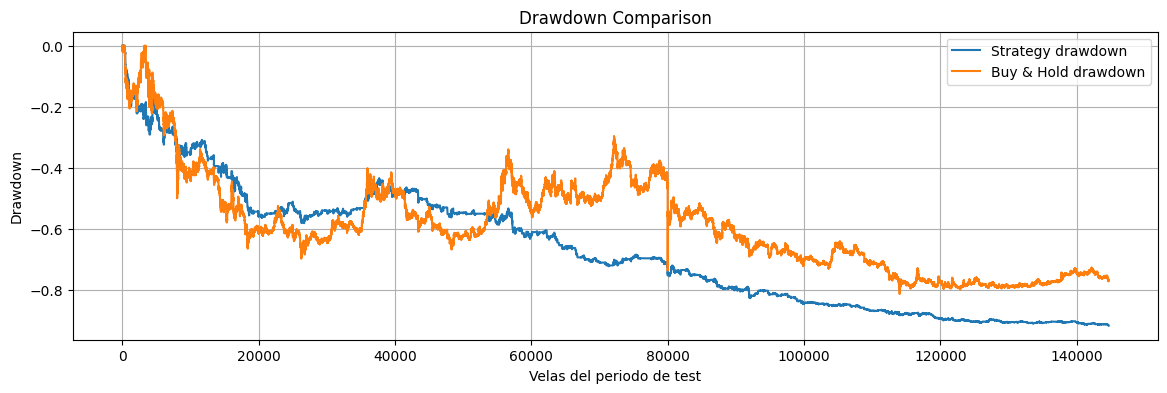

In [10]:
# ============================================================
# Drawdown comparison
# Esta visualización muestra la caída porcentual desde el máximo acumulado de cada estrategia.
# El drawdown permite evaluar el riesgo asumido, no solo la rentabilidad final.
# En trading, una estrategia rentable puede no ser aceptable si durante el camino sufre pérdidas intermedias demasiado elevadas.
# ============================================================

plt.figure(figsize=(14, 4))
plt.plot(bt["drawdown"], label="Strategy drawdown")
plt.plot(bt["buy_hold_drawdown"], label="Buy & Hold drawdown")
plt.title("Drawdown Comparison")
plt.xlabel("Velas del periodo de test")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación del drawdown

El gráfico de drawdown confirma que ambas estrategias atraviesan periodos de pérdidas profundas durante el conjunto de test. Sin embargo, la estrategia basada en machine learning presenta un drawdown máximo incluso más severo que el benchmark Buy & Hold.

Esto indica que el sistema no consigue proteger adecuadamente el capital en fases prolongadas de tendencia bajista. Aunque las reglas de Stop Loss y cooldown ayudan a controlar parcialmente algunas operaciones individuales, no son suficientes para compensar la debilidad estructural de una estrategia exclusivamente alcista en este contexto de mercado.

El drawdown cercano al 90% refleja además un aspecto importante del trading algorítmico: una estrategia puede mantener cierta capacidad predictiva local y aun así deteriorar progresivamente la cartera si el contexto global del mercado es desfavorable.

Desde el punto de vista financiero, este tipo de comportamiento sería difícilmente asumible en un entorno real, lo que justifica la necesidad de incorporar mecanismos adicionales de gestión de riesgo o filtros de régimen de mercado en futuras iteraciones del sistema.

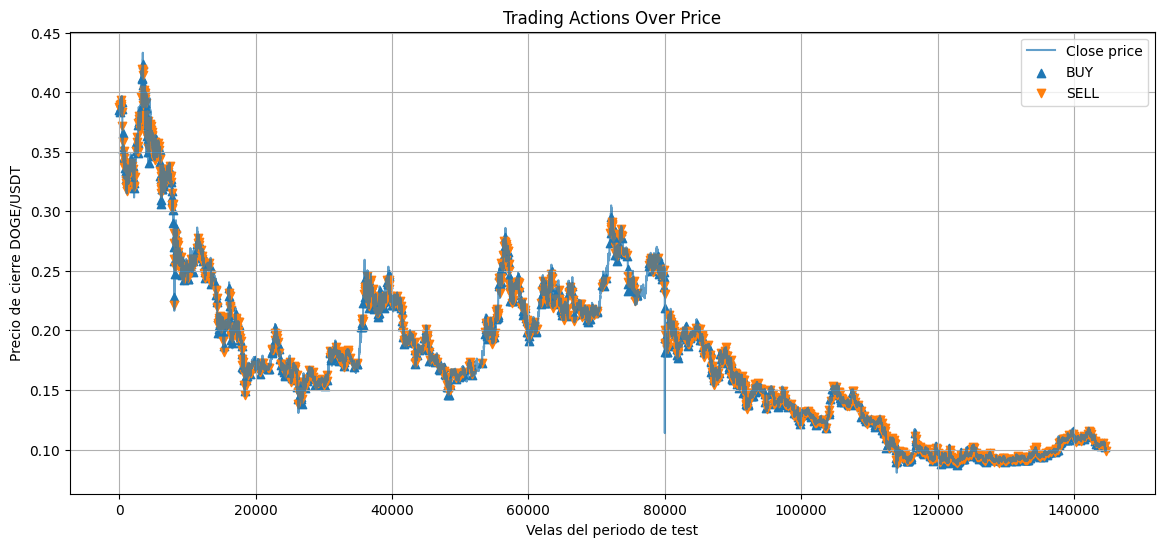

In [11]:
# ============================================================
# Trading actions over price
# Esta gráfica representa las compras y ventas generadas por la estrategia sobre la serie de precios.
# Sirve para comprobar visualmente si las entradas y salidas tienen sentido respecto al movimiento del mercado.
# También ayuda a detectar comportamientos problemáticos, como sobreoperación, entradas tardías o ventas demasiado frecuentes.
# ============================================================

plt.figure(figsize=(14, 6))
plt.plot(bt["close"], label="Close price", alpha=0.7)

buys = bt[bt["action"] == "BUY"]
sells = bt[bt["action"] == "SELL"]

plt.scatter(buys.index, buys["close"], marker="^", label="BUY")
plt.scatter(sells.index, sells["close"], marker="v", label="SELL")

plt.title("Trading Actions Over Price")
plt.xlabel("Velas del periodo de test")
plt.ylabel("Precio de cierre DOGE/USDT")
plt.legend()
plt.grid(True)
plt.show()

### Interpretación de las operaciones sobre el precio

La representación de compras y ventas sobre la serie temporal permite observar que el sistema genera señales de entrada y salida de forma relativamente frecuente a lo largo de todo el periodo de test.

La mayoría de las operaciones se producen siguiendo pequeños movimientos locales del precio, pero el contexto general continúa siendo claramente bajista. Esto provoca que muchas entradas long terminen atrapadas dentro de una tendencia descendente de mayor escala.

También puede observarse que la estrategia permanece activa incluso durante fases donde el mercado muestra una debilidad sostenida. Esto sugiere que el modelo es capaz de detectar movimientos alcistas de corto plazo, pero no distingue adecuadamente entre rebotes temporales y cambios reales de tendencia.

En conjunto, el gráfico refuerza la idea de que el sistema actual funciona más como un detector local de movimientos que como un modelo adaptado a diferentes regímenes de mercado.

# Conclusión

En este notebook se ha evaluado el modelo XGBoost como parte de una estrategia de trading simulada sobre DOGE/USDT. A diferencia de la evaluación mediante métricas de clasificación, el backtesting permite analizar el comportamiento financiero del sistema bajo condiciones más cercanas a un escenario real.

La estrategia incorpora comisiones, reglas de entrada y salida, cooldown entre operaciones, Take Profit, Stop Loss y comparación contra una estrategia pasiva Buy & Hold. Esto permite valorar no solo si el modelo predice correctamente la dirección del precio, sino si dichas predicciones pueden transformarse en decisiones de trading con una relación razonable entre rentabilidad y riesgo.

Los resultados obtenidos muestran una limitación importante del sistema actual: la estrategia implementada es exclusivamente long-only. Durante el periodo de test, el mercado presenta un comportamiento predominantemente bajista, caracterizado por caídas prolongadas y rebotes alcistas relativamente débiles. En este contexto, el modelo consigue detectar algunos movimientos positivos de corto plazo, pero la tendencia general del mercado termina dominando el comportamiento de la cartera.

La comparación contra Buy & Hold muestra que ambas estrategias sufren pérdidas severas, aunque la estrategia activa basada en XGBoost presenta un deterioro todavía mayor. Esto evidencia que obtener métricas de clasificación aceptables no implica necesariamente construir un sistema rentable desde el punto de vista financiero.

Además, el análisis de drawdown y de las operaciones ejecutadas sugiere que el modelo funciona principalmente como detector local de movimientos alcistas, sin incorporar todavía mecanismos suficientes para adaptarse a diferentes regímenes de mercado. El sistema continúa operando incluso en fases claramente bajistas, donde una estrategia exclusivamente alcista parte con una desventaja estructural.

A partir de estas limitaciones, el siguiente notebook del proyecto se centrará en una segunda versión del sistema de backtesting orientada a mejorar la robustez de la estrategia. Entre las posibles líneas de mejora se encuentran:

- Incorporación de filtros de régimen de mercado
- Reducción de exposición en contextos bajistas
- Introducción de lógica de posiciones short de forma simulada
- Gestión dinámica del tamaño de posición
- Uso de filtros de volatilidad y tendencia
- Mayor permanencia en liquidez en escenarios de incertidumbre

El objetivo de estas mejoras no será únicamente aumentar la rentabilidad, sino construir una estrategia más adaptativa y robusta frente a distintos contextos de mercado. Esto resulta especialmente relevante en entornos financieros altamente volátiles como el mercado de criptomonedas.

Finalmente, los resultados deberán interpretarse con cautela, ya que el backtest sigue siendo una simulación y no contempla todos los elementos de una ejecución real, como slippage, latencia, liquidez disponible o diferencias entre precio teórico y precio ejecutado. Aun así, constituye una validación mucho más sólida que las métricas predictivas aisladas y permite identificar limitaciones relevantes del sistema antes de plantear una posible ejecución en entorno testnet.